In [1]:
import pandas as pd
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
    'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label'
]

df = pd.read_csv('/content/kddcup.data_10_percent_corrected', header=None, names=column_names)

In [2]:
df.head(5)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494021 non-null  int64  
 1   protocol_type                494021 non-null  object 
 2   service                      494021 non-null  object 
 3   flag                         494021 non-null  object 
 4   src_bytes                    494021 non-null  int64  
 5   dst_bytes                    494021 non-null  int64  
 6   land                         494021 non-null  int64  
 7   wrong_fragment               494021 non-null  int64  
 8   urgent                       494021 non-null  int64  
 9   hot                          494021 non-null  int64  
 10  num_failed_logins            494021 non-null  int64  
 11  logged_in                    494021 non-null  int64  
 12  num_compromised              494021 non-null  int64  
 13 

**DATA CLEANING PROCESS**

In [4]:
df.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


There are no null values -> hence, no need of handling missing values

In [5]:
print(f"The current dataset shape: {df.shape}")
print(f"Duplicates: {df.duplicated().sum()}")

The current dataset shape: (494021, 42)
Duplicates: 348435


In [6]:
df = df.drop_duplicates()
print(f"Modified dataset shape: {df.shape}")

Modified dataset shape: (145586, 42)


There are ≈350K duplicates which are dropped. This is crucial to avoid overfitting and to reduce unneccessary data volume.

**Categorical Encoding and Correcting Inconsistencies**


1.   Checking for and clearing text inconsistencies (to avoid multiple unique issue)
2.   Type conversion of numerical features
3. Categorical encoding (Usually One-hot encoding to avoid accidental priority assignment)



In [7]:
cols = ['protocol_type', 'service', 'flag', 'label']
for col in cols:
  print(f"{col}: {df[col].unique()}")


protocol_type: ['tcp' 'udp' 'icmp']
service: ['http' 'smtp' 'finger' 'domain_u' 'auth' 'telnet' 'ftp' 'eco_i' 'ntp_u'
 'ecr_i' 'other' 'private' 'pop_3' 'ftp_data' 'rje' 'time' 'mtp' 'link'
 'remote_job' 'gopher' 'ssh' 'name' 'whois' 'domain' 'login' 'imap4'
 'daytime' 'ctf' 'nntp' 'shell' 'IRC' 'nnsp' 'http_443' 'exec' 'printer'
 'efs' 'courier' 'uucp' 'klogin' 'kshell' 'echo' 'discard' 'systat'
 'supdup' 'iso_tsap' 'hostnames' 'csnet_ns' 'pop_2' 'sunrpc' 'uucp_path'
 'netbios_ns' 'netbios_ssn' 'netbios_dgm' 'sql_net' 'vmnet' 'bgp' 'Z39_50'
 'ldap' 'netstat' 'urh_i' 'X11' 'urp_i' 'pm_dump' 'tftp_u' 'tim_i' 'red_i']
flag: ['SF' 'S1' 'REJ' 'S2' 'S0' 'S3' 'RSTO' 'RSTR' 'RSTOS0' 'OTH' 'SH']
label: ['normal.' 'buffer_overflow.' 'loadmodule.' 'perl.' 'neptune.' 'smurf.'
 'guess_passwd.' 'pod.' 'teardrop.' 'portsweep.' 'ipsweep.' 'land.'
 'ftp_write.' 'back.' 'imap.' 'satan.' 'phf.' 'nmap.' 'multihop.'
 'warezmaster.' 'warezclient.' 'spy.' 'rootkit.']


All categorial values are already consistent with no whitespaces.


> To note: 'label' is binary mapped and encoded later since this is just the data cleaning and processing phase for normalization and feature selection




In [8]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in num_cols:
  df[col] = df[col].astype('float64')

print("Converted numerical features:")
df.info()

Converted numerical features:
<class 'pandas.core.frame.DataFrame'>
Index: 145586 entries, 0 to 494020
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     145586 non-null  float64
 1   protocol_type                145586 non-null  object 
 2   service                      145586 non-null  object 
 3   flag                         145586 non-null  object 
 4   src_bytes                    145586 non-null  float64
 5   dst_bytes                    145586 non-null  float64
 6   land                         145586 non-null  float64
 7   wrong_fragment               145586 non-null  float64
 8   urgent                       145586 non-null  float64
 9   hot                          145586 non-null  float64
 10  num_failed_logins            145586 non-null  float64
 11  logged_in                    145586 non-null  float64
 12  num_compromised              1455

Type conversion of numerical features to 'float64' dtype is done. This ensures normalization is carried out smoothly.

In [9]:
!pip install category_encoders
import category_encoders as ce
#One-hot encoding for all categorical features
df_paper = pd.get_dummies(df.copy(), columns=['protocol_type', 'service', 'flag'])
#Hybrid approach of one hot encoding and binary encoding
df_hybrid = pd.get_dummies(df.copy(), columns=['protocol_type', 'flag'])
be = ce.BinaryEncoder(cols=['service'])
df_hybrid = be.fit_transform(df_hybrid)

print(f"Paper approach shape: {df_paper.shape}")
print(f"Hybrid approach shape: {df_hybrid.shape}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.9 MB/s eta 0:00:00
Paper approach shape: (145586, 119)
Hybrid approach shape: (145586, 60)


**Paper approach**:
The research paper mentions the use of one hot encoding for all categorical X values. However, this methodology is computationally heavy since 'service' feature is high cardinal.


---


**Hybrid approach**
This approach uses one hot enconding for low cardinal features ['protocol_type' and 'flag'] and binary encoding for 'service' attribute which drastically reduces the number of columns. Used for comparison in its accuracy with the former method.



> To note: Label encoding is often avoided (especially in NNs) to avoid the accidental assumption of order or rank.



MAPPING TAGRET VALUES FOR CLASSIFICATION

In [10]:
#Map the 'label' values into binary values
df_hybrid['label'] = df_hybrid['label'].apply(lambda x: 0 if x == 'normal.' else 1)
df_paper['label'] = df_paper['label'].apply(lambda x: 0 if x == 'normal.' else 1)

print(f"Label values in dataset mapping: {df_hybrid['label'].unique()}")

Label values in dataset mapping: [0 1]


TRAIN/TEST SPLIT + NORMALIZATION

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


top_features = ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent',
                'hot', 'num_failed_logins', 'num_compromised', 'root_shell', 'count']
X_p = df_paper.drop('label', axis=1)
X_p_top = X_p[top_features]
y_p = df_paper['label']
X_ptrain, X_ptest, y_ptrain, y_ptest = train_test_split(X_p_top, y_p, test_size=0.2, random_state=42)

# 2. SCALING (Result is a NumPy array, which is why we lose column names here)
scaler = MinMaxScaler()
X_ptrain_scaled = scaler.fit_transform(X_ptrain)
X_ptest_scaled = scaler.transform(X_ptest)

MODEL TRAINING

To note: imports - multiple times for personal learning

In [ ]:
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

#for cross val
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
fold_no = 1
cv_scores = []
best_val_acc = 0  # track the highest score

for train_index, val_index in skf.split(X_ptrain_scaled, y_ptrain):
    print(f"\n--- Starting Fold {fold_no} ---")

    X_f_train, X_f_val = X_ptrain_scaled[train_index], X_ptrain_scaled[val_index]
    y_f_train, y_f_val = y_ptrain.iloc[train_index], y_ptrain.iloc[val_index]

    X_f_train = X_f_train.reshape(X_f_train.shape[0], 10, 1)
    X_f_val = X_f_val.reshape(X_f_val.shape[0], 10, 1)

    # Architecture
    model = models.Sequential([
        layers.Conv1D(32, kernel_size=3, activation='relu', input_shape=(10, 1)),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(2, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(X_f_train, y_f_train,
              epochs=50,
              batch_size=64,
              validation_data=(X_f_val, y_f_val),
              verbose=1)

    _, acc = model.evaluate(X_f_val, y_f_val, verbose=0)
    cv_scores.append(acc)
    print(f"Fold {fold_no} Accuracy: {acc:.4f}")

    if acc > best_val_acc:
        best_val_acc = acc
        model.save('best_paper_cnn_model.h5')
        print(f"--- New best model saved (Acc: {acc:.4f}) ---")

    fold_no += 1

print(f"\nAverage 5-Fold Accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")




--- Starting Fold 1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9599 - loss: 0.1551 - val_accuracy: 0.9642 - val_loss: 0.1334
Epoch 2/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9622 - loss: 0.1411 - val_accuracy: 0.9633 - val_loss: 0.1341
Epoch 3/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9629 - loss: 0.1393 - val_accuracy: 0.9650 - val_loss: 0.1314
Epoch 4/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9631 - loss: 0.1388 - val_accuracy: 0.9651 - val_loss: 0.1309
Epoch 5/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9633 - loss: 0.1378 - val_accuracy: 0.9654 - val_loss: 0.1305
Epoch 6/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9632 - loss: 0.1371 - val_accuracy: 0.9650 - val_loss: 0.1295
Epoch 7/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9633 - loss: 0.1367 - val_accuracy: 0.9641 - val_loss: 0.1307
Epoch 8/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9633 - loss: 0.1359 -

Fold 1 Accuracy: 0.9767
--- New best model saved (Acc: 0.9767) ---

--- Starting Fold 2 ---
Epoch 1/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9599 - loss: 0.1556 - val_accuracy: 0.9631 - val_loss: 0.1340
Epoch 2/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9621 - loss: 0.1407 - val_accuracy: 0.9634 - val_loss: 0.1364
Epoch 3/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9625 - loss: 0.1391 - val_accuracy: 0.9643 - val_loss: 0.1327
Epoch 4/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9627 - loss: 0.1386 - val_accuracy: 0.9646 - val_loss: 0.1319
Epoch 5/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9628 - loss: 0.1379 - val_accuracy: 0.9642 - val_loss: 0.1332
Epoch 6/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9635 - loss: 0.1373 - val_accuracy: 0.9641 - val_loss: 0.1312
Epoch 7/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9632 - loss: 0.1357 - val_accuracy: 0.9646 - val_loss: 0.13

Fold 2 Accuracy: 0.9769
--- New best model saved (Acc: 0.9769) ---

--- Starting Fold 3 ---
Epoch 1/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9587 - loss: 0.1554 - val_accuracy: 0.9623 - val_loss: 0.1382
Epoch 2/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9624 - loss: 0.1391 - val_accuracy: 0.9626 - val_loss: 0.1415
Epoch 3/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9632 - loss: 0.1376 - val_accuracy: 0.9627 - val_loss: 0.1334
Epoch 4/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9633 - loss: 0.1357 - val_accuracy: 0.9625 - val_loss: 0.1352
Epoch 5/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9636 - loss: 0.1350 - val_accuracy: 0.9633 - val_loss: 0.1334
Epoch 6/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9638 - loss: 0.1340 - val_accuracy: 0.9640 - val_loss: 0.1313
Epoch 7/50
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9636 - loss: 0.1334 - val_accuracy: 0.9638 - val_loss: 0.13

In [ ]:
import tensorflow as tf
from sklearn.metrics import classification_report, roc_auc_score

print("\n--- FINAL TEST EVALUATION (THE UNSEEN DATA) ---")

final_best_model = tf.keras.models.load_model('best_paper_cnn_model.h5')

# 2. Reshape to 3D for CNN
X_ptest_cnn = X_ptest_scaled.reshape(X_ptest_scaled.shape[0], 10, 1)

y_pred_probs = final_best_model.predict(X_ptest_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

test_acc = np.sum(y_pred == y_ptest) / len(y_ptest)
test_auc = roc_auc_score(y_ptest, y_pred_probs[:, 1])

print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final AUC-ROC: {test_auc:.4f}")
print("\nFull Report:")
print(classification_report(y_ptest, y_pred, target_names=['Normal', 'Threat']))


--- FINAL TEST EVALUATION (THE UNSEEN DATA) ---
910/910 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Final Test Accuracy: 0.9765
Final AUC-ROC: 0.9950

Full Report:
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98     17610
      Threat       0.99      0.95      0.97     11508

    accuracy                           0.98     29118
   macro avg       0.98      0.97      0.98     29118
weighted avg       0.98      0.98      0.98     29118



In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
fold_no = 1
cv_scores = []
best_val_acc = 0

# Early stopping if val_loss doesn't improve for 10 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

for train_index, val_index in skf.split(X_ptrain_scaled, y_ptrain):
    print(f"\n--- Starting ANN Fold {fold_no} ---")

    X_f_train, X_f_val = X_ptrain_scaled[train_index], X_ptrain_scaled[val_index]
    y_f_train, y_f_val = y_ptrain.iloc[train_index], y_ptrain.iloc[val_index]

    model = models.Sequential([
        layers.Input(shape=(10,)),

        # Hidden Layer 1: 128 neurons, ReLU
        layers.Dense(128, activation='relu'),

        # HL2: 64 neurons, ReLU
        layers.Dense(64, activation='relu'),

        # HL3: 32 neurons, ReLU
        layers.Dense(32, activation='relu'),

        # Output Layer: Softmax for classification (2 for Normal/Threat)
        layers.Dense(2, activation='softmax')
    ])

    optimizer_sgd = SGD(learning_rate=0.01, momentum=0.9)

    model.compile(optimizer=optimizer_sgd,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(X_f_train, y_f_train,
              epochs=100,
              batch_size=64,
              validation_data=(X_f_val, y_f_val),
              callbacks=[early_stop],
              verbose=1)

    _, acc = model.evaluate(X_f_val, y_f_val, verbose=0)
    cv_scores.append(acc)
    print(f"Fold {fold_no} Accuracy: {acc:.4f}")

    if acc > best_val_acc:
        best_val_acc = acc
        model.save('best_paper_ann_model.h5')
        print(f"--- New best ANN saved (Acc: {acc:.4f}) ---")

    fold_no += 1

print(f"\nAverage 5-Fold ANN Accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")


--- Starting ANN Fold 1 ---
Epoch 1/100
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9404 - loss: 0.1867 - val_accuracy: 0.9584 - val_loss: 0.1503
Epoch 2/100
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9568 - loss: 0.1559 - val_accuracy: 0.9582 - val_loss: 0.1491
Epoch 3/100
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9570 - loss: 0.1525 - val_accuracy: 0.9586 - val_loss: 0.1485
Epoch 4/100
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9569 - loss: 0.1478 - val_accuracy: 0.9590 - val_loss: 0.1383
Epoch 5/100
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9591 - loss: 0.1448 - val_accuracy: 0.9641 - val_loss: 0.1421
Epoch 6/100
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9608 - loss: 0.1434 - val_accuracy: 0.9645 - val_loss: 0.1341
Epoch 7/100
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9613 - loss: 0.1425 - val_accuracy: 0.9642 - val_loss: 0.1352
Epoch 8/100
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step

Fold 1 Accuracy: 0.9662
--- New best ANN saved (Acc: 0.9662) ---

--- Starting ANN Fold 2 ---
Epoch 1/100
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9478 - loss: 0.1833 - val_accuracy: 0.9582 - val_loss: 0.1514
Epoch 2/100
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9569 - loss: 0.1567 - val_accuracy: 0.9584 - val_loss: 0.1474
Epoch 3/100
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9569 - loss: 0.1529 - val_accuracy: 0.9587 - val_loss: 0.1424
Epoch 4/100
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9572 - loss: 0.1468 - val_accuracy: 0.9636 - val_loss: 0.1381
Epoch 5/100
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9599 - loss: 0.1447 - val_accuracy: 0.9611 - val_loss: 0.1386
Epoch 6/100
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9616 - loss: 0.1424 - val_accuracy: 0.9564 - val_loss: 0.1592
Epoch 7/100
1456/1456 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9615 - loss: 0.1421 - val_accuracy: 0.9632 - val_lo

In [ ]:
print("\n--- FINAL ANN TEST EVALUATION ---")
final_best_ann = tf.keras.models.load_model('best_paper_ann_model.h5')

y_pred_probs = final_best_ann.predict(X_ptest_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_ptest, y_pred, target_names=['Normal', 'Threat']))
print(f"Final ANN AUC-ROC: {roc_auc_score(y_ptest, y_pred_probs[:, 1]):.4f}")


--- FINAL ANN TEST EVALUATION ---
910/910 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.97     17610
      Threat       0.98      0.93      0.95     11508

    accuracy                           0.97     29118
   macro avg       0.97      0.96      0.96     29118
weighted avg       0.97      0.97      0.97     29118

Final ANN AUC-ROC: 0.9793


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

print("--- Starting SVM Baseline (Accelerated via Subsampling) ---")

#random sample of 20,000 rows for training
train_df = pd.DataFrame(X_ptrain_scaled)
train_df['label'] = y_ptrain.values
sample_df = train_df.sample(n=20000, random_state=42)

X_sample = sample_df.drop('label', axis=1).values
y_sample = sample_df['label'].values

svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42, verbose=True)
svm_model.fit(X_sample, y_sample)

y_svm_pred = svm_model.predict(X_ptest_scaled)
y_svm_probs = svm_model.predict_proba(X_ptest_scaled)[:, 1]

print("\n--- SVM FINAL PERFORMANCE REPORT ---")
print(classification_report(y_ptest, y_svm_pred, target_names=['Normal', 'Threat']))
print(f"SVM AUC-ROC: {roc_auc_score(y_ptest, y_svm_probs):.4f}")

--- Starting SVM Baseline (Accelerated via Subsampling) ---
[LibSVM]
--- SVM FINAL PERFORMANCE REPORT ---
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.97     17610
      Threat       0.98      0.93      0.95     11508

    accuracy                           0.96     29118
   macro avg       0.97      0.96      0.96     29118
weighted avg       0.96      0.96      0.96     29118

SVM AUC-ROC: 0.9746


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import roc_curve, auc, confusion_matrix

cnn_model = tf.keras.models.load_model('best_paper_cnn_model.h5')
ann_model = tf.keras.models.load_model('best_paper_ann_model.h5')

X_ptest_cnn = X_ptest_scaled.reshape(X_ptest_scaled.shape[0], 10, 1)

# 3. Generate Probabilities (Needed for ROC Curves)
cnn_probs = cnn_model.predict(X_ptest_cnn)[:, 1]
ann_probs = ann_model.predict(X_ptest_scaled)[:, 1]
svm_probs = svm_model.predict_proba(X_ptest_scaled)[:, 1]

# 4. Generate Class Predictions (Needed for Confusion Matrices)
cnn_preds = np.argmax(cnn_model.predict(X_ptest_cnn), axis=1)
ann_preds = np.argmax(ann_model.predict(X_ptest_scaled), axis=1)
svm_preds = svm_model.predict(X_ptest_scaled)

910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
910/910 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
910/910 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


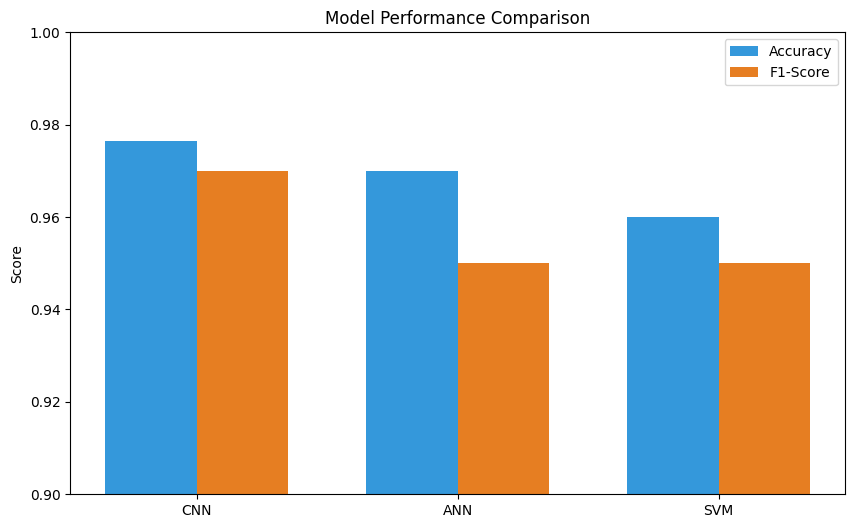

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Using the results you just got
models = ['CNN', 'ANN', 'SVM']
accuracies = [0.9765, 0.9700, 0.9600]
f1_scores = [0.97, 0.95, 0.95]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#3498db')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='#e67e22')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.90, 1.0) # Zoomed in to show differences
ax.legend()

plt.show()

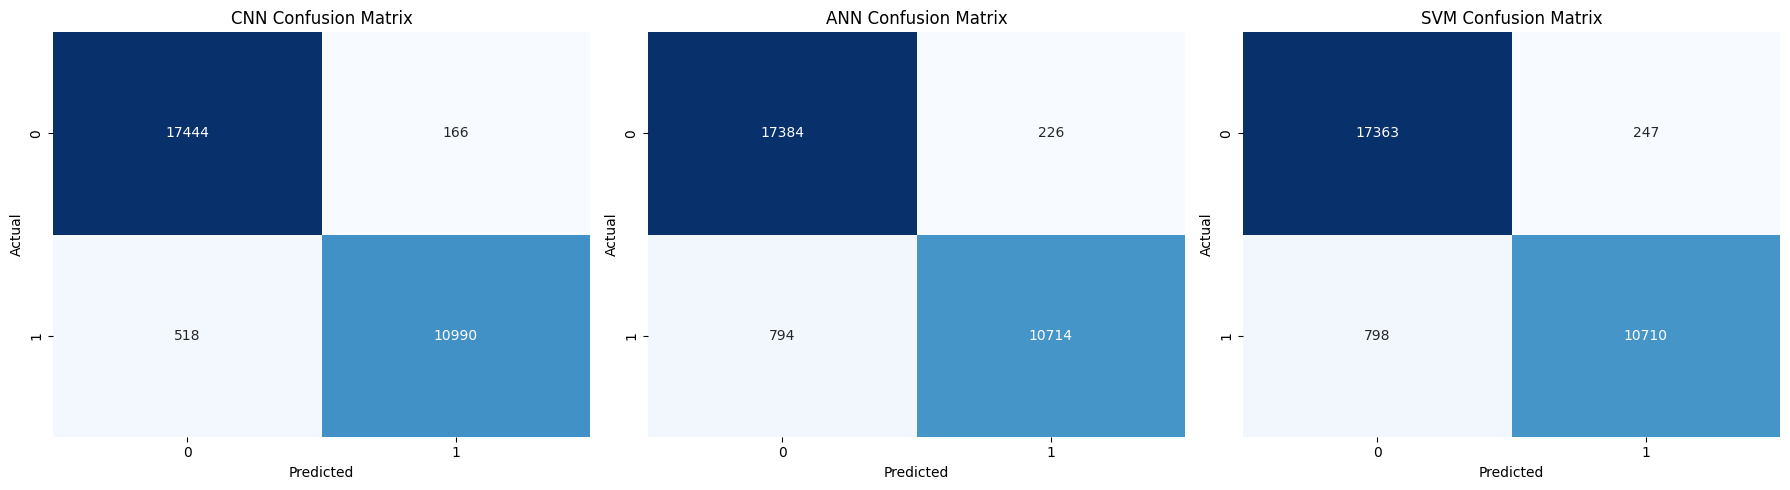

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = ['CNN', 'ANN', 'SVM']
all_preds = [cnn_preds, ann_preds, svm_preds]

for i, preds in enumerate(all_preds):
    cm = confusion_matrix(y_ptest, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{model_names[i]} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

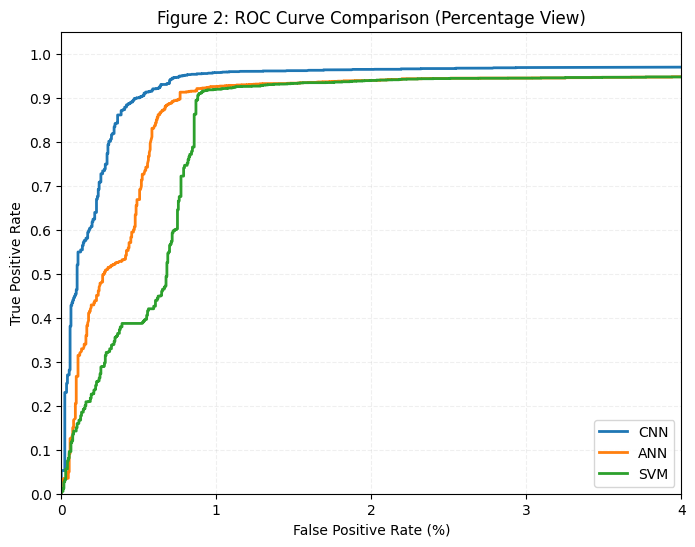

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for name, probs in model_data.items():
    fpr, tpr, _ = roc_curve(y_ptest, probs)

    fpr_percent = fpr * 100

    plt.plot(fpr_percent, tpr, lw=2, label=f'{name}')

plt.xlim([0.0, 4.0])
plt.ylim([0.0, 1.05])

plt.xticks([0.00, 1.00, 2.00, 3.00, 4.00])
plt.yticks(np.arange(0, 1.1, 0.1))

plt.xlabel('False Positive Rate (%)')
plt.ylabel('True Positive Rate')
plt.title('Figure 2: ROC Curve Comparison (Percentage View)')
plt.grid(alpha=0.2, linestyle='--')
plt.legend()
plt.show()

DRAFTED FOR FUTURE REF (RCE)

In [ ]:
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.model_selection import train_test_split

# #TT split and normalize hybrid dataset
# X_h = df_hybrid.drop('label', axis=1)
# y_h = df_hybrid['label']
# X_htrain, X_htest, y_htrain, y_htest = train_test_split(X_h, y_h, test_size=0.2, random_state=42)
# scalar_h = MinMaxScaler()
# X_htrain_scaled = scalar_h.fit_transform(X_htrain)
# X_htest_scaled = scalar_h.transform(X_htest)

# #TT split and normalize paper dataset
# X_p = df_paper.drop('label', axis=1)
# y_p = df_paper['label']
# X_ptrain, X_ptest, y_ptrain, y_ptest = train_test_split(X_p, y_p, test_size=0.2, random_state=42)
# scalar_p = MinMaxScaler()
# X_ptrain_scaled = scalar_p.fit_transform(X_ptrain)
# X_ptest_scaled = scalar_p.transform(X_ptest)


**FEATURE SELECTION**


1.   PCA - Principle Component Analysis
2.   RFE - Recursive Feature Elimination



In [ ]:
# from sklearn.feature_selection import RFE
# from sklearn.ensemble import RandomForestClassifier

# estimator = RandomForestClassifier(random_state=42)

# selector_h = RFE(estimator=estimator, n_features_to_select=10, step=1)
# selector_p = RFE(estimator=estimator, n_features_to_select=10, step=1)

# selector_h.fit(X_htrain_scaled, y_htrain)
# selector_p.fit(X_ptrain_scaled, y_ptrain)

# X_htrain_final = selector_h.transform(X_htrain_scaled)
# X_htest_final = selector_h.transform(X_htest_scaled)

# X_ptrain_final = selector_p.transform(X_ptrain_scaled)
# X_ptest_final = selector_p.transform(X_ptest_scaled)

In [ ]:
# X_ptrain_final.shape

(116468, 10)

In [ ]:
# print(X_ptest_final[:5])

[[0.         0.         0.45988258 0.03       0.05       0.02352941
  0.02       0.         1.         0.        ]
 [0.         0.         0.35420744 0.06       0.06       0.04313725
  0.04       0.         1.         0.        ]
 [0.         0.         0.19178082 0.05       0.07       0.01960784
  0.02       0.         1.         0.        ]
 [0.         0.         0.27201566 0.14       0.05       0.02745098
  0.03       0.         1.         0.        ]
 [0.         0.         0.49706458 0.07       0.06       0.06666667
  0.07       0.         1.         0.        ]]


In [ ]:
# hybrid_top_10 = X_h.columns[selector_h.support_]
# print("Hybrid Top 10 Features:", hybrid_top_10.tolist())

Hybrid Top 10 Features: ['src_bytes', 'dst_bytes', 'hot', 'count', 'same_srv_rate', 'diff_srv_rate', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_same_src_port_rate', 'flag_SF']


In [ ]:
# paper_top_10 = X_p.columns[selector_p.support_]
# print("Paper Top 10 Features:", paper_top_10.tolist())

Paper Top 10 Features: ['src_bytes', 'dst_bytes', 'count', 'same_srv_rate', 'diff_srv_rate', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_same_src_port_rate', 'service_private', 'flag_SF']
